In [3]:
import numpy as np
from case_studies import *

# https://en.wikipedia.org/wiki/Wolfe_conditions For c_1 and c_2 choice
#def wolfe_line_search(f, df, x, p, c1=1e-4, c2=0.9, max_iter=1000):
#    a = 1.0
#    fx = f(x)
#    grad_x = df(x)
#    for _ in range(max_iter):
#        new_x = x + a * p
#        if f(new_x) > fx + c1 * a * np.dot(p, grad_x):
#            a *= 0.5  # Reduce step size
#        elif np.dot(p, df(new_x)) < c2 * np.dot(p, grad_x):
#            a *= 2.0  # Increase step size
#        else:
#            break
#    return a

def is_pos_def(H):
    return np.all(np.linalg.eigvals(H) > 0)

def backtrack(f, df, x, p, alpha_init=1.0, rho=0.5, c1=1e-4):
    fx = f(x)
    grad_x = df(x)
    alpha = alpha_init
    while f(x + alpha * p) > fx + c1 * alpha * np.dot(grad_x, p):
        alpha *= rho
    return alpha

# Newton's Method function (updated version)
def newtons_method(f, df, Hf, x0, max_iter=10000, epsilon=1e-6):
    x = x0.copy()
    xs = [x]
    for _ in range(max_iter):
        if np.linalg.norm(df(x)) < epsilon: break
        H = Hf(x)
        if np.linalg.eigvals(H).min() > 0:  # Check if Hessian is positive definite
            p = -np.linalg.solve(H, df(x))
        else:
            eigvals, eigvecs = np.linalg.eigh(H)
            new_H = sum((1 / abs(l)) * np.outer(v, v) for l, v in zip(eigvals, eigvecs.T))
            p = -new_H @ df(x)
        alpha = backtrack(f, df, x, p, 1.0)
        x = x + alpha * p
        xs.append(x)
    return np.array(xs)

# Steepest Descent function (updated version)
def steepest_descent(f, df, x0, max_iter=10000, epsilon=1e-6):
    x = x0.copy()
    xs = [x]
    for _ in range(max_iter):
        if np.linalg.norm(df(x)) < epsilon: break
        p = -df(x)
        alpha = backtrack(f, df, x, p, 1.0)
        x = x + alpha * p
        xs.append(x)
    return np.array(xs)


# Newton's Method function (updated version)
def CG(Q, g, epsilon=1e-6):
    cgc = 0 #CG step count
    x_k = 0
    nabla_f_k = g
    p_k = -nabla_f_k
    for _ in range(len(g)):
        cgc += 1
        Qp_k = Q @ p_k
        a_k = -(np.transpose(p_k) @ nabla_f_k / (np.transpose(p_k) @ Qp_k))
        x_k = x_k + a_k * p_k
        nabla_f_k = Q @ x_k + g
        
        if np.linalg.norm(nabla_f_k) < epsilon: break

        upper = np.transpose(nabla_f_k.T) @ Qp_k
        lower = np.transpose(p_k @ Qp_k)
        
        p_k = -nabla_f_k + (upper/lower) * p_k
    
    return x_k, cgc

def newton_CG(f, df, Hf, x_0, c1=1e-4, rho=0.5, max_iter=1000, epsilon=1e-6, rate=2):
    cgcl = [] #CG step count list
    x_k = x_0
    xs = [x_k]
    
    for _ in range(max_iter):
        nabla_f_k = df(x_k)
        if np.linalg.norm(nabla_f_k) < epsilon: break
        
        if (rate == 0):                                                     #linear
            eta_k = 0.5
        elif (rate == 1):                                                   #superlinear
            eta_k = 0.5 * min(0.5, np.linalg.norm(nabla_f_k))
        else:                                                               #Quadratic
            eta_k = 0.5 * min(0.5, np.sqrt(np.linalg.norm(nabla_f_k)))
            
        epsilon_k = eta_k * np.linalg.norm(nabla_f_k)
        
        Q_k = Hf(x_k)        
        p_k, cgc = CG(Q_k, nabla_f_k, epsilon_k)
        cgcl.append(cgc)
        a_k = backtrack(f, df, x_k, p_k, 1.0, rho, c1)
        x_k = x_k + a_k * p_k
        xs.append(x_k)
    
    return np.array(xs), np.array(cgcl)

In [4]:
def testPrint():
    x0_f1 = np.random.randn(5)
    x0_f2 = np.random.randn(2)
    x0_f3 = np.random.randn(5)
    x0_f4 = np.random.randn(5)
    x0_f5 = np.random.randn(5)

    print("Steepest Descent Results:")
    print("f1:", steepest_descent(f1, df1, x0_f1)[0])
    print("f2:", steepest_descent(f2, df2, x0_f2)[0])
    print("f3:", steepest_descent(f3, df3, x0_f3)[0])
    print("f4:", steepest_descent(f4, df4, x0_f4)[0])
    print("f5:", steepest_descent(f5, df5, x0_f5)[0])

    # Running Newton's Method
    print("\nNewton's Method Results:")
    print("f1:", newtons_method(f1, df1, Hf1, x0_f1)[0])
    print("f2:", newtons_method(f2, df2, Hf2, x0_f2)[0])
    print("f3:", newtons_method(f3, df3, Hf3, x0_f3)[0])
    print("f4:", newtons_method(f4, df4, Hf4, x0_f4)[0])
    print("f5:", newtons_method(f5, df5, Hf5, x0_f5)[0])

    # Running Newton_CG Method
    print("\nNewton's Method Results:")
    a, b = newton_CG(f1, df1, Hf1, x0_f1)
    print("f1:", a[0], b)
    a, b = newton_CG(f2, df2, Hf2, x0_f2)
    print("f2:", a[0], b)
    a, b = newton_CG(f3, df3, Hf3, x0_f3)
    print("f3:", a[0], b)
    a, b = newton_CG(f4, df4, Hf4, x0_f4)
    print("f4:", a[0], b)
    a, b = newton_CG(f5, df5, Hf5, x0_f5)
    print("f5:", a[0], b)
    
#testPrint()

[ 37.49564525 -37.93452413  10.72655903  17.37241371  42.36019913
 -47.39325999  18.96420917  17.01430452  14.37232266 -38.36108046
 -20.02784027  42.21761515  33.51196539 -49.62796833  39.65122956
 -35.0456735  -35.6501925   16.90262743  46.57840851  19.95124158]


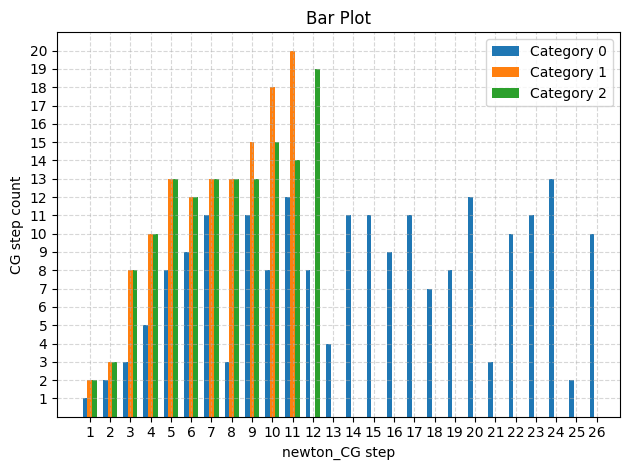

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from case_studies import *

def CGCBarPlot(cgcll):
    categories = len(cgcll)
    max_length = max(len(cgcl) for cgcl in cgcll)
    x = np.arange(1, max_length + 1)
    
    bar_width = 0.7 / categories
    offsets = np.linspace(-bar_width * (categories - 1) / 2, bar_width * (categories - 1) / 2, categories)

    for i, cgcl in enumerate(cgcll):
        X = x[:len(cgcl)] + offsets[i]
        plt.bar(X, cgcl, width=bar_width, label=f"Category {i}")
    
    plt.xlabel("newton_CG step")
    plt.ylabel("CG step count")
    plt.xticks(range(1,max_length+1))
    plt.yticks(range(1,max([max(cgcl) for cgcl in cgcll])+1))
    plt.title("Bar Plot")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


d = 20
xs = np.random.uniform(-50, 50+1, size=d)
print(xs)
_, L = newton_CG(f1, df1, Hf1, xs, rate=0)
_, S = newton_CG(f1, df1, Hf1, xs, rate=1)
_, Q = newton_CG(f1, df1, Hf1, xs, rate=2)
CGCBarPlot([L, S, Q])

[ 39  -5  23 -18  15 -46   3 -37   8 -19 -33 -46  31  39 -21  48  -5  42
  -7 -30   8 -17 -10  38  -5 -42 -40  13 -47  49 -29 -41 -34 -26  34 -37
  22  -1 -39 -38 -15  28  -3  19 -10  50  18  22  15 -13  24 -48 -49 -26
  31  21  43   0  37   9  32  37   8  48  23 -20   1 -32 -23  37 -38  19
  43 -22 -45 -46 -40  27 -13  33 -31 -14 -22  29 -18 -11 -29  13 -21 -17
 -14 -14  23 -14  -1  33 -42  39  30 -42]


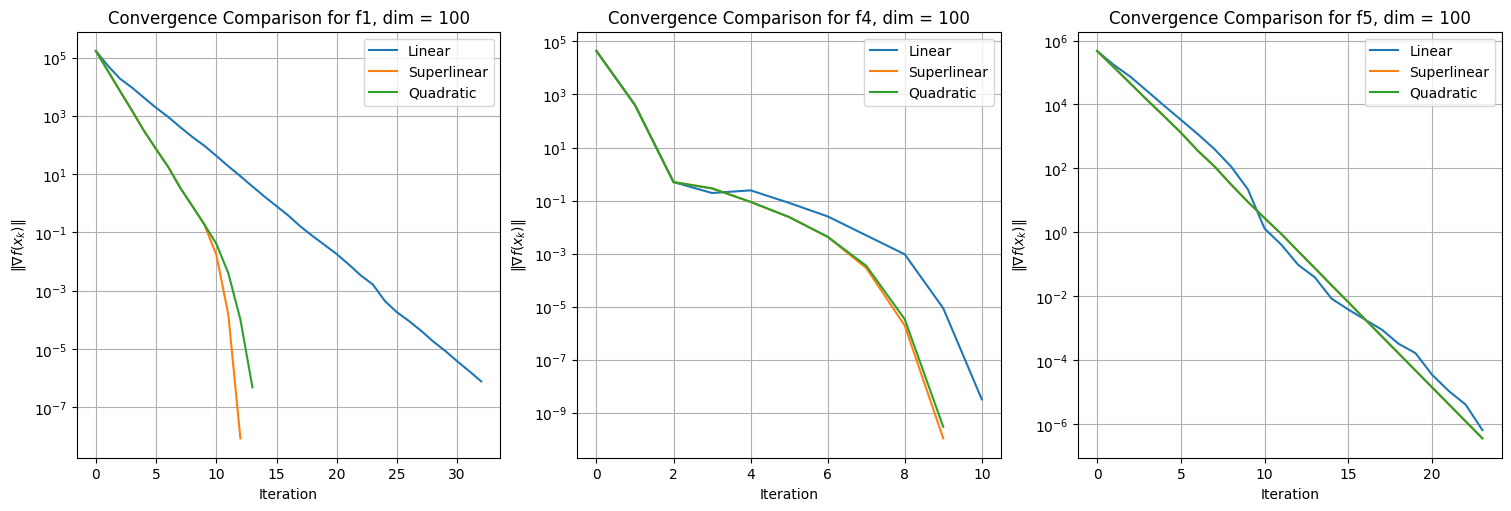

In [6]:
def evaluate_and_plot(f, df, Hf, x_0, fname, ax, dim):
    types = ["Linear", "Superlinear", "Quadratic"]

    for i, label in enumerate(types):
        xs, _ = newton_CG(f, df, Hf, x_0, rate=i)
        norms = [np.linalg.norm(df(x)) for x in xs]
        # norms = [np.linalg.norm(x - x_opt(fname, len(x))) for x in xs]
        ax.plot(norms, label=label)
    
    ax.set_yscale("log")
    ax.grid()
    ax.set_xlabel("Iteration")
    ax.set_ylabel(r"$\|\nabla f(x_k)\|$")
    #ax.set_ylabel(r"$\|x_k - x^*\|$")
    ax.set_title(f"Convergence Comparison for {fname}, dim = {dim}")
    ax.legend()

fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

dim = 100
x_0 = np.random.randint(-50, 50+1, size=dim)
#x_0 = np.random.randn(dim)

print(x_0)

evaluate_and_plot(f1, df1, Hf1, x_0, "f1", axes[0], dim)
evaluate_and_plot(f4, df4, Hf4, x_0, "f4", axes[1], dim)
evaluate_and_plot(f5, df5, Hf5, x_0, "f5", axes[2], dim)

plt.show()

[ 40  12  47  48  36  32 -49   9  16 -10  40 -29  43   9 -38  26   1 -16
 -48 -11]


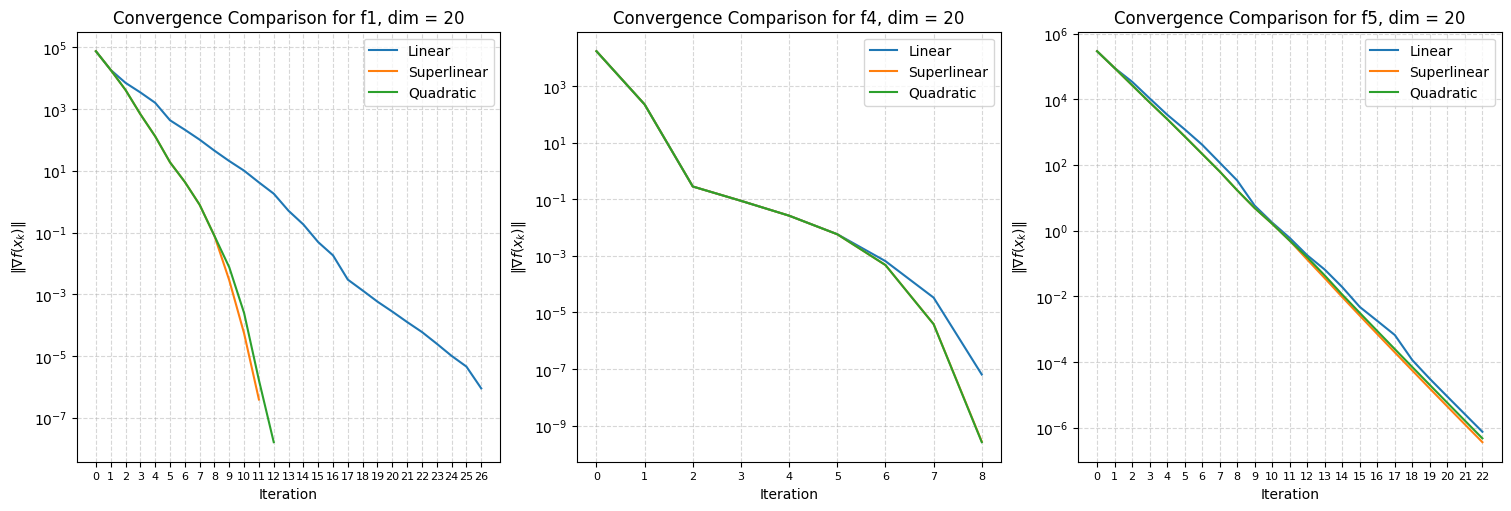

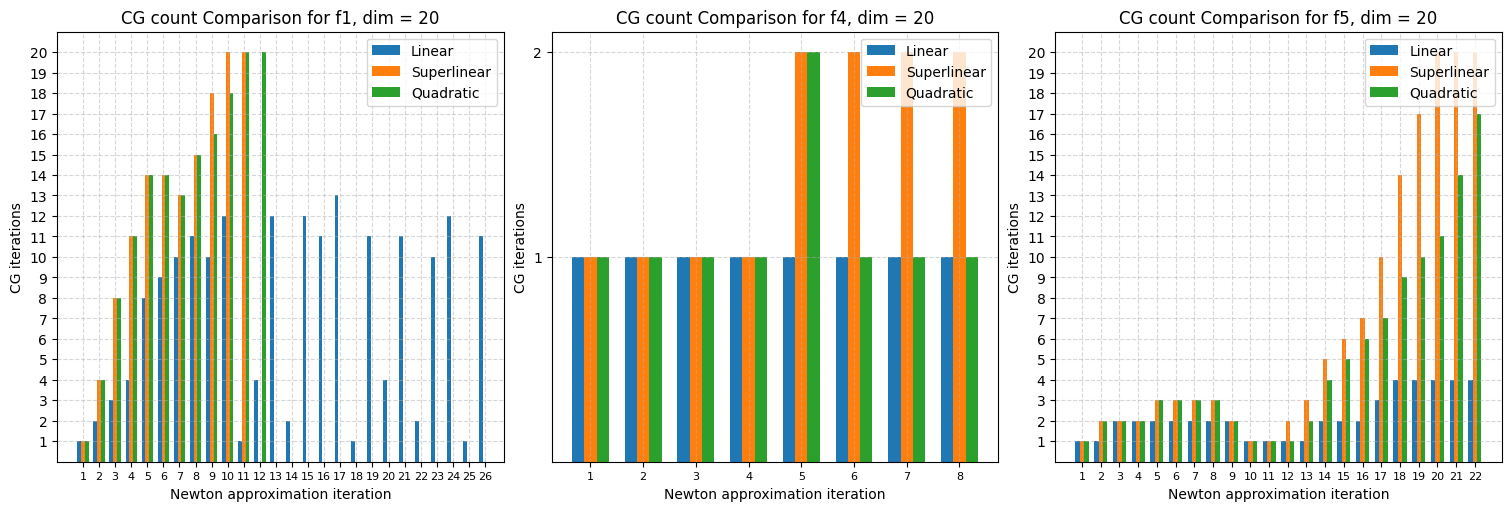

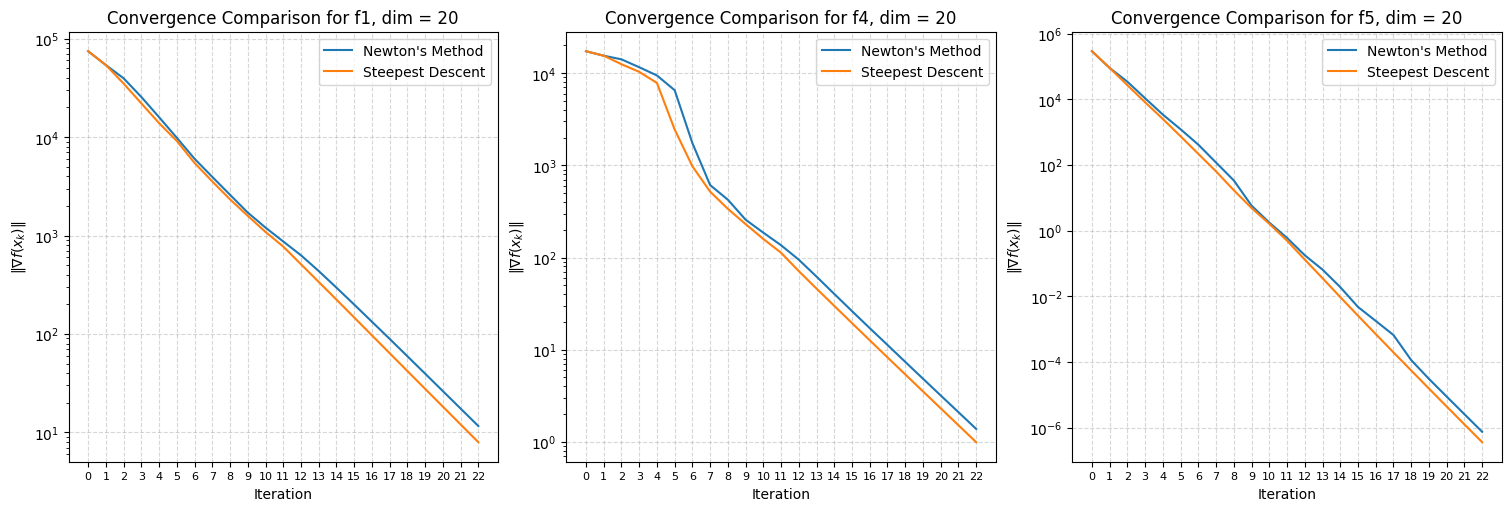

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from case_studies import *

def ConvergencePlot(F, XX, types, dim):
    fig, axes = plt.subplots(1, len(F), figsize=(15, 5), constrained_layout=True)
    for i, X in enumerate(XX):
        max_length = max(len(xs) for xs in X)
        for j, label in enumerate(types):
            norms = [np.linalg.norm(F[i][2](x)) for x in X[j]]
            # norms = [np.linalg.norm(x - x_opt(fname, len(x))) for x in xs]
            axes[i].plot(norms, label=label)
        
        axes[i].set_yscale("log")
        axes[i].grid(True, linestyle='--', alpha=0.5)
        axes[i].set_xlabel("Iteration")
        axes[i].set_ylabel(r"$\|\nabla f(x_k)\|$")
        #axes[i].set_ylabel(r"$\|x_k - x^*\|$")
        axes[i].set_xticks(range(max_length))
        axes[i].set_xticklabels(range(max_length), fontsize=8)   
        axes[i].set_title(f"Convergence Comparison for {F[i][0]}, dim = {dim}")
        axes[i].legend()

    plt.show()

def CGCPlot(F, CC, types, dim):
    fig, axes = plt.subplots(1, len(F), figsize=(15, 5), constrained_layout=True)
    for i, C in enumerate(CC):
        categories = len(C)
        max_length = max(len(cgc) for cgc in C)
        x = np.arange(1, max_length + 1)
        
        bar_width = 0.7 / categories
        offsets = np.linspace(-bar_width * (categories - 1) / 2, bar_width * (categories - 1) / 2, categories)

        for j, cgc in enumerate(C):
            X = x[:len(cgc)] + offsets[j]
            axes[i].bar(X, cgc, width=bar_width, label=types[j])
        
        axes[i].set_xlabel("Newton approximation iteration")
        axes[i].set_ylabel("CG iterations")
        axes[i].set_xticks(range(1,max_length+1))
        axes[i].set_xticklabels(range(1,max_length+1), fontsize=8)  
        axes[i].set_yticks(range(1,max([max(cgc) for cgc in C])+1))
        axes[i].set_title(f"CG count Comparison for {F[i][0]}, dim = {dim}")
        axes[i].legend(loc='upper right')
        axes[i].grid(True, linestyle='--', alpha=0.5)
    # plt.tight_layout()

    plt.show()


dim = 20
rng = np.random.default_rng()
x_0 = rng.integers(low=-50, high=50+1, size=dim)

print(x_0)
F1 = np.array(["f1", f1, df1, Hf1])
F2 = np.array(["f2", f2, df2, Hf2])
F3 = np.array(["f3", f3, df3, Hf3])
F4 = np.array(["f4", f4, df4, Hf4])
F5 = np.array(["f5", f5, df5, Hf5])
F = np.array([F1, F4, F5])
types = ["Linear", "Superlinear", "Quadratic"]
XX = []
CC = []
for f in F:
    X = []
    C = []
    for i in range(len(types)): 
        xs, cgc = newton_CG(f[1], f[2], f[3], x_0, rate=i)
        X.append(xs)
        C.append(cgc)
    XX.append(X)
    CC.append(C)

ConvergencePlot(F, XX, types, dim)
CGCPlot(F, CC, types, dim)


types2 = ["Newton's Method", "Steepest Descent"]
XX2 = []
for f in F:
    X2 = []
    for i in range(len(types2)): 
        X2.append(newtons_method(f[1], f[2], f[3], x_0))
        X2.append(steepest_descent(f[1], f[2], x_0))
    XX2.append(X)
ConvergencePlot(F, XX2, types2, dim) 
